In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [39]:
class MLP_MNIST(nn.Module):
  def __init__(self):
    super().__init__()

    self.mlp_stack = nn.Sequential(
        nn.Linear(784,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,10)
    )

  def forward(self,x):
    x = x.view(x.shape[0],-1)
    return self.mlp_stack(x)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
model = MLP_MINST().to(device)

cpu


In [30]:
tranform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tranform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=tranform
)

train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False
)

torch.Size([128, 1, 28, 28])


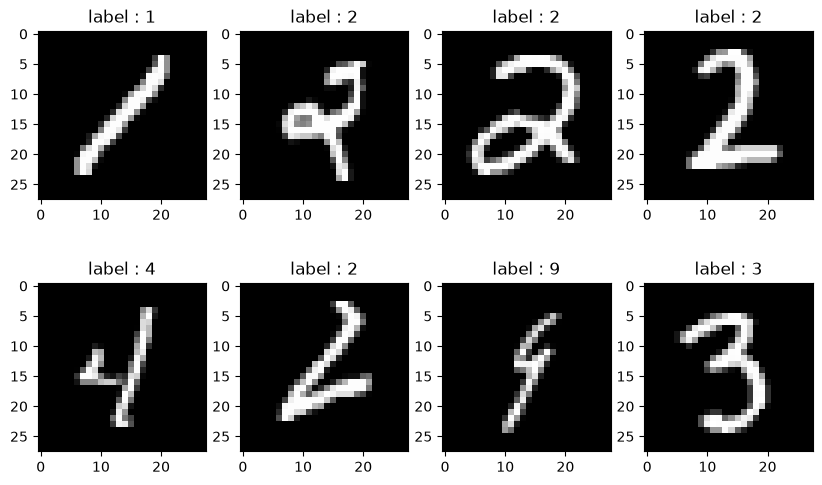

In [31]:
images,lables = next(iter(train_loaders))
print(images.shape)
plt.figure(figsize=(10,6))
for i in range(8):
    image = images[i]
    image = image.permute(1,2,0)
    label = lables[i]
    plt.subplot(2,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(f"label : {label}")
    

In [32]:
#Hyper-paramaeters
nums_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [33]:
def train_loop(model,train_loader,criterion,optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images,labels in train_loader:
        images = images.to(device)
        labels = lables.to(device)

        #prediction
        logits = model(images)

        #compute Loss
        loss = criterion(logits,labels)

        #backpropogation

        optimizer.zero_grad()
        loss.backward()

        #weight update
        optimizer.step()

        running_loss+=loss.item()

        predictions = torch.argmax(logits,dim = 1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
    
        print(f"Train Loss : {epoch_loss:.4f} | Train Acc : {epoch_acc:.4f}")


In [42]:
for epochs in range(nums_epochs):
    train_loop(model,train_loaders,criterion,optimizer)

Train Loss : 0.0049 | Train Acc : 0.1250
Train Loss : 0.0098 | Train Acc : 0.1250
Train Loss : 0.0147 | Train Acc : 0.1224
Train Loss : 0.0196 | Train Acc : 0.1230
Train Loss : 0.0245 | Train Acc : 0.1234
Train Loss : 0.0294 | Train Acc : 0.1237
Train Loss : 0.0343 | Train Acc : 0.1239
Train Loss : 0.0392 | Train Acc : 0.1240
Train Loss : 0.0441 | Train Acc : 0.1241
Train Loss : 0.0490 | Train Acc : 0.1242
Train Loss : 0.0539 | Train Acc : 0.1236
Train Loss : 0.0588 | Train Acc : 0.1237
Train Loss : 0.0637 | Train Acc : 0.1238
Train Loss : 0.0686 | Train Acc : 0.1239
Train Loss : 0.0735 | Train Acc : 0.1234
Train Loss : 0.0784 | Train Acc : 0.1235
Train Loss : 0.0833 | Train Acc : 0.1236
Train Loss : 0.0882 | Train Acc : 0.1237
Train Loss : 0.0931 | Train Acc : 0.1238
Train Loss : 0.0980 | Train Acc : 0.1238
Train Loss : 0.1029 | Train Acc : 0.1235
Train Loss : 0.1078 | Train Acc : 0.1239
Train Loss : 0.1127 | Train Acc : 0.1243
Train Loss : 0.1176 | Train Acc : 0.1243
Train Loss : 0.1

ValueError: Expected input batch_size (96) to match target batch_size (128).